# Notation macroéconomique des pays par Clustering hiérarchique — IMF WEO
## Objectif
Nous sommes missionnés pour regrouper les pays selon des indicateurs macroéconomiques clés et leur attribuer une note. La note est data-driven : on clusterise d’abord (sans supervision), puis on ordonne les clusters selon une performance macro agrégée.

## Données
Source : IMF — World Economic Outlook (WEO) depuis le [site du FMI](https://www.imf.org/en/publications/weo/weo-database/2024/april?utm_source=chatgpt.com)

Indicateurs retenus
| **Indicateur**                              | **Description (EN)**                                                   |
|----------------------------------------|--------------------------------------------------------------------|
| **PIB par habitant (USD courants)**       | Gross domestic product per capita, current prices — U.S. dollars  |
| **Croissance du PIB réel (% chg)**         | Gross domestic product, constant prices — Percent change          |
| **Inflation moyenne (% chg)**              | Inflation, average consumer prices — Percent change               |
| **Dette publique brute (% du PIB)**        | General government gross debt — Percent of GDP                    |
| **Solde budgétaire (% du PIB)**            | General government net lending/borrowing — Percent of GDP         |
| **Compte courant (% du PIB)**              | Current account balance — Percent of GDP                          |

## Import 

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [ ]:
chemin = Path().resolve().parent
data = pd.read_csv(chemin/"data/data.csv")

## Aperçu des Données 

In [ ]:
df = data.copy()
print(f"Nombre de ligne :{df.shape[0]}\nNombre de colonne : {df.shape[1]} ")

df.head(5)

Nombre de ligne :194
Nombre de colonne : 8 


,Country,GDP_growth,GDP_per_capita,Inflation,Unemployment,Debt,Deficit,Current_account
0,Afghanistan,-6.240,422.229,10.600,NaN,10.925,-0.997,13.974
1,Albania,3.080,8924.317,3.495,11.0,58.022,-2.163,-3.754
2,Algeria,3.848,5721.678,7.551,NaN,46.401,-8.510,0.136
3,Andorra,1.800,44899.596,4.266,1.5,34.727,2.282,17.488
4,Angola,2.558,2431.580,22.004,NaN,70.342,2.726,4.853


## Nettoyage et préparation 

In [ ]:
# retirer la colonne Unemployment (trop de valeurs manquantes)
df = df.drop(columns=["Unemployment"])
df = df.dropna()
df = df.reset_index(drop=True)
print(f"le nombre de pays retenu : {df.shape[0]}")


le nombre de pays retenu : 191


In [ ]:
countries = df["Country"]
X = df.drop(columns=["Country"])

# Vérification rapide des stats
print("\n Aperçu des statistiques globales: ")
display(df.describe())



 Aperçu des statistiques globales: 


,GDP_growth,GDP_per_capita,Inflation,Debt,Deficit,Current_account
count,191.000000,191.000000,191.000000,191.000000,191.000000,191.000000
mean,3.164466,18259.832654,12.757450,61.614775,-2.919613,-1.755911
std,3.509484,24001.382267,47.519408,40.522306,5.379098,9.370474
min,-10.000000,230.044000,-0.239000,0.000000,-42.484000,-42.002000
25%,1.887500,2579.068500,2.548000,37.232000,-4.613500,-5.639500
50%,3.000000,7327.118000,3.800000,55.550000,-2.984000,-2.055000
75%,4.473000,23835.458000,6.178000,76.025500,-1.118000,2.325000
max,33.895000,131384.164000,560.981000,283.195000,27.286000,32.493000


## Standardisation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Clustering hierarchique (Ward)


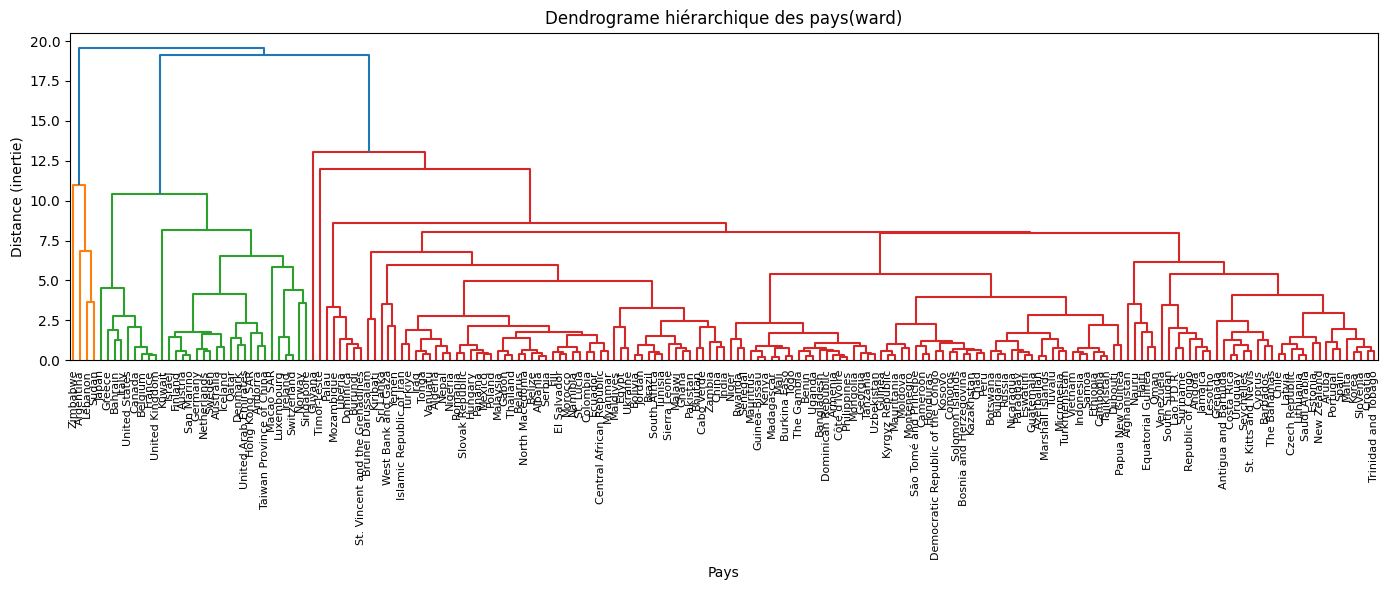

In [ ]:
Z = linkage(X_scaled, method="ward")

# Dendograme
plt.figure(figsize=(14,6))
dendrogram(Z, labels=countries.values, leaf_rotation=90, leaf_font_size=8)
plt.title("Dendrograme hiérarchique des pays(ward)")
plt.xlabel("Pays")
plt.ylabel("Distance (inertie)")
plt.tight_layout()
plt.show()

A vue d'oiel, on voit clairement 3 cluster de pays, on va donc decouper en 3 cluster et attribuer les notes A, B, C

### Découpage en 3 clusters 
On choisit 3 classes de notation(A,B,C)

In [ ]:
n_clusters = 3
labels = fcluster(Z, criterion="maxclust", t=3)

df["Cluster"] = labels
df.head()

,Country,GDP_growth,GDP_per_capita,Inflation,Debt,Deficit,Current_account,Cluster
0,Afghanistan,-6.240,422.229,10.600,10.925,-0.997,13.974,3
1,Albania,3.080,8924.317,3.495,58.022,-2.163,-3.754,3
2,Algeria,3.848,5721.678,7.551,46.401,-8.510,0.136,3
3,Andorra,1.800,44899.596,4.266,34.727,2.282,17.488,2
4,Angola,2.558,2431.580,22.004,70.342,2.726,4.853,3


### Taille et résumé des clusters

In [ ]:
cluster_summary = df.groupby("Cluster").agg(
    n_pays=("Country", "count"),
    PIB_moyen = ("GDP_per_capita", "mean"),
    Croissance_moy = ("GDP_growth", "mean"),
    Inflation_moy = ("Inflation", "mean"),
    Dette_moy = ("Debt", "mean"),
    solde_moy = ("Deficit", "mean"),
    Courant_moy = ("Current_account", "mean"),
    
)

print("=== Synthèse par cluster ===")
display(cluster_summary.round(2))


=== Synthèse par cluster ===


,n_pays,PIB_moyen,Croissance_moy,Inflation_moy,Dette_moy,solde_moy,Courant_moy
Cluster,,,,,,,
1,4,4682.39,-3.44,281.88,187.05,-4.65,-10.47
2,31,62861.47,1.84,2.61,72.62,-0.22,7.48
3,156,9744.83,3.60,7.87,56.21,-3.41,-3.37


## Interpretation macroéconomique des clusters

| Cluster | Note | Taille |profil macoéconomique synthètique|
|-----------|-----------|-----------|-----|
| 2         | A         | 31 pays      |Economies développées : PIB/hab élevé, inflation matrisée, dette soutenable     |
| 3         | B         | 156 pays         |Economies émergentes : croissance soutenue, inflation modérée, dette moyenne     |
| 1         | C         | 4 pays         |Economie en crie : croissance négative, inflation élevée, dette excessive     |

Ce regroupement hiérarchique en 3 classes permet de visualiser rapidement la santé macroécnomique mondiale:  
* Les pays du groupe A affichent une stabilité structurelle, les B un potentiel de croissance et les Cnécessite des politique de stabilité 


#### Visualisation des pays representant le 1er cluster 

In [ ]:
df.query('Cluster==1')

,Country,GDP_growth,GDP_per_capita,Inflation,Debt,Deficit,Current_account,Cluster
6,Argentina,-2.764,12811.840,249.793,86.200,0.009,0.910,1
92,Lebanon,-10.000,3283.414,171.195,283.195,-6.133,-36.081,1
158,Sudan,-4.201,546.707,145.535,280.313,-2.530,-6.918,1
190,Zimbabwe,3.196,2087.614,560.981,98.483,-9.930,0.212,1


#### Visualisation des pays representant le 2er cluster 

In [ ]:
# Affichons les 15 premiers pays ordonné par PIB decroissant 
df.query('Cluster==2').sort_values(by=["GDP_per_capita"]).head(10)

,Country,GDP_growth,GDP_per_capita,Inflation,Debt,Deficit,Current_account,Cluster
62,Greece,2.038,23965.779,2.749,158.791,-0.932,-6.530,2
12,Bahrain,3.567,28876.454,1.400,125.972,-6.894,6.932,2
88,Kuwait,-1.437,31723.933,3.168,7.082,27.286,30.115,2
81,Japan,0.855,33138.163,2.237,254.556,-6.536,3.469,2
163,Taiwan Province of China,3.072,34431.965,1.881,22.497,-0.539,13.897,2
79,Italy,0.709,39579.560,1.673,139.228,-4.618,0.783,2
3,Andorra,1.800,44899.596,4.266,34.727,2.282,17.488,2
57,France,0.744,47358.557,2.417,111.627,-4.891,-0.578,2
180,United Kingdom,0.460,51074.793,2.453,104.347,-4.581,-2.596,2
78,Israel,1.609,53371.545,2.448,67.342,-8.162,5.590,2
